# Set Covering Problem — Constructive Heuristics
### Exercise 1.1 — CH1, CH2, CH3, redundancy elimination and experiments

This notebook, after the construction of three constructive heuristics and applied redundancy elimination (RE), develops and implements two iterative improvement algorithms (first-improvement (FI) and best-improvement (BI)) for the SCP problem. 

### The notebook covers:


## 1. Imports and configuration

`DATA_DIR` is relative to the notebook's current working directory. The data is in the `SCP-Instances/`, in the same directory.

In [1]:
import heapq
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("SCP-Instances")
SEED = 42


## 2. OR-Library SCP format

Each instance has the form

```text
m n
c_1 ... c_n
k_1 <k_1 column indices>
...
k_m <k_m column indices>
```

Here `m` is the number of elements (rows) and `n` is the number of available sets (columns). The file uses **1-based** column indices; the implementation converts them to **0-based** indices.

In [2]:
def read_scp_instance(filepath):
    """Read one SCP instance in OR-Library format.

    Format:
        m n
        c_1 ... c_n
        k_1 <k_1 column indices (1-based)>
        ...
        k_m <k_m column indices (1-based)>

    Returns dict containing m, n, costs array, rows list, and cols list.
    """
    filepath = Path(filepath)
    tokens = filepath.read_text().split()
    if len(tokens) < 2:
        raise ValueError(f"{filepath}: file is too short to contain m and n")

    values = [int(x) for x in tokens]
    idx = 0
    m, n = values[idx], values[idx + 1]
    idx += 2

    if m <= 0 or n <= 0:
        raise ValueError(f"{filepath}: invalid dimensions m={m}, n={n}")

    costs = np.asarray(values[idx : idx + n], dtype=float)
    idx += n

    rows = []
    for e in range(m):
        k = values[idx]
        idx += 1
        covering = [c - 1 for c in values[idx : idx + k]]  # Convert to 0-based
        idx += k
        rows.append(covering)

    cols = [[] for _ in range(n)]
    for e, covering in enumerate(rows):
        for j in covering:
            cols[j].append(e)

    return {"m": m, "n": n, "costs": costs, "rows": rows, "cols": cols}


## 3. Incremental solution state

The central idea is to avoid repeatedly recomputing coverage from scratch. For a partial solution we maintain:

| State | Meaning | Update/query | 
|---|---|---|
| `chosen[j]` | set `j` is selected | O(1) lookup | 
| `cover_count[e]` | number of selected sets covering element `e` | updated only when a set is added/removed | 
| `uncovered` + `_pos` | current uncovered elements | O(1) swap-remove/append | 
| `gain[j]` | number of currently uncovered elements that set `j` would cover | maintained incrementally | 
| `solution_cost` | total cost of selected sets | O(1) update | 

The key candidate condition is `gain[j] > 0`. Therefore a redundant set (`gain == 0`) is never selected during construction.

When an element changes from uncovered to covered, every set containing that element loses one unit of gain. During RE, the reverse update restores that gain if the element becomes uncovered again.

In [3]:
class SCPInstance:
    """Maintains incremental solution state for Set Covering Problem.

    State variables maintained in O(1) / O(k):
    - chosen: boolean mask of selected sets
    - cover_count: number of selected sets covering element e
    - gain: number of uncovered elements covered by set j
    - uncovered & _pos: O(1) list for fast sampling and state maintenance
    - solution_cost: total cost of currently chosen sets
    """

    def __init__(self, data, name=None):
        self.name = name
        self.m, self.n = data["m"], data["n"]
        self.costs = np.asarray(data["costs"], dtype=float)
        self.rows = data["rows"] # element -> covering sets (lists)
        self.cols = data["cols"]  # set -> covered elements (lists)
        self.rows_np = [np.asarray(r, dtype=np.int64) for r in self.rows]
        self.cols_np = [np.asarray(c, dtype=np.int64) for c in self.cols]
        self.col_size = np.asarray([len(c) for c in self.cols], dtype=np.int64)
        self.reset()

    # ---------------------------------------------------------------- state
    def reset(self):
        self.chosen = np.zeros(self.n, dtype=bool)
        self.cover_count = np.zeros(self.m, dtype=np.int64)
        self.gain = self.col_size.copy()    # nothing covered yet -> gain = column size
        self.uncovered = list(range(self.m))  # list of uncovered elements
        self._pos = np.arange(self.m, dtype=np.int64) # position of each element inside `uncovered`
        self.solution_cost = 0.0

    def snapshot(self):
        """Return a deep copy snapshot of current state."""
        return {
            "chosen": self.chosen.copy(),
            "cover_count": self.cover_count.copy(),
            "gain": self.gain.copy(),
            "uncovered": self.uncovered.copy(),
            "_pos": self._pos.copy(),
            "solution_cost": float(self.solution_cost),
        }

    def restore(self, state):
        """Restore instance state from a snapshot."""
        self.chosen = state["chosen"].copy()
        self.cover_count = state["cover_count"].copy()
        self.gain = state["gain"].copy()
        self.uncovered = state["uncovered"].copy()
        self._pos = state["_pos"].copy()
        self.solution_cost = float(state["solution_cost"])

    def is_complete_cover(self):
        return len(self.uncovered) == 0

    def solution_sets(self):
        return np.flatnonzero(self.chosen).tolist()
    
    # ------------------------------------------------ O(1) uncovered-list ops
    def _mark_covered(self, e):
        pos = int(self._pos[e])
        last = self.uncovered.pop()
        if last != e:
            self.uncovered[pos] = last
            self._pos[last] = pos
        self.gain[self.rows_np[e]] -= 1

    def _mark_uncovered(self, e):
        self._pos[e] = len(self.uncovered)
        self.uncovered.append(e)
        self.gain[self.rows_np[e]] += 1

    # ------------------------------------------------------------ mutations
    def add_set(self, j):
        j = int(j)
        if self.chosen[j]:
            return 0
        self.chosen[j] = True
        self.solution_cost += self.costs[j]

        els = self.cols_np[j]
        self.cover_count[els] += 1
        newly_covered = els[self.cover_count[els] == 1]
        for e in newly_covered:
            self._mark_covered(int(e))
        return len(newly_covered)

    def remove_set(self, j):
        j = int(j)
        if not self.chosen[j]:
            return 0
        self.chosen[j] = False
        self.solution_cost -= self.costs[j]

        els = self.cols_np[j]
        self.cover_count[els] -= 1
        newly_uncovered = els[self.cover_count[els] == 0]
        for e in newly_uncovered:
            self._mark_uncovered(int(e))
        return len(newly_uncovered)
    
    # -------------------------------------------------------------- queries
    def is_removable(self, j):
        """A set is removable if all its covered elements are covered by >= 2 sets."""
        return bool(np.all(self.cover_count[self.cols_np[int(j)]] > 1))
    
    # -------------------------------------------------------- verification
    def check_solution(self):
        """Verify feasibility and cost correctness."""
        covered = np.zeros(self.m, dtype=bool)
        for j in np.flatnonzero(self.chosen):
            covered[self.cols_np[j]] = True
        if not covered.all():
            raise AssertionError(f"{self.name}: incomplete set cover")
        if not np.isclose(self.solution_cost, self.costs[self.chosen].sum()):
            raise AssertionError(f"{self.name}: cost mismatch")

## 4. Instance loading and best-known solutions

The filename convention used here maps names such as `scp42.txt` to instance label `4.2`, and `scpA3.txt` to `A.3`. Duplicate labels are rejected rather than silently overwritten.

The Best Known Solution (BKS) dictionary is kept separate from the heuristic code so that the percentage-deviation calculation is easy to audit.

In [4]:
FNAME_RE = re.compile(r"scp([A-Za-z]|\d)(\d+)", re.IGNORECASE)

def label_from_filename(path):
    match = FNAME_RE.search(Path(path).name)
    if not match:
        return None
    group, num = match.groups()
    return f"{group.upper()}.{num}"

def sort_key(label):
    cls, num = label.split(".")
    return (cls, int(num))

def load_all_instances(data_dir):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        return {}

    instances = {}
    for path in sorted(data_dir.iterdir()):
        if not path.is_file():
            continue
        label = label_from_filename(path)
        if label is None:
            continue
        if label in instances:
            raise ValueError(f"Duplicate instance label {label!r}: multiple files match it")
        instances[label] = SCPInstance(read_scp_instance(path), name=label)

    return dict(sorted(instances.items(), key=lambda kv: sort_key(kv[0])))

BKS = {
    "4.1": 429, "4.2": 512, "4.3": 516, "4.4": 494, "4.5": 512,
    "4.6": 560, "4.7": 430, "4.8": 492, "4.9": 641, "4.10": 514,
    "5.1": 253, "5.2": 302, "5.3": 226, "5.4": 242, "5.5": 211,
    "5.6": 213, "5.7": 293, "5.8": 288, "5.9": 279, "5.10": 265,
    "6.1": 138, "6.2": 146, "6.3": 145, "6.4": 131, "6.5": 161,
    "A.1": 253, "A.2": 252, "A.3": 232, "A.4": 234, "A.5": 236,
    "B.1": 69,  "B.2": 76,  "B.3": 80,  "B.4": 79,  "B.5": 72,
    "C.1": 227, "C.2": 219, "C.3": 243, "C.4": 219, "C.5": 215,
    "D.1": 60, "D.2": 66, "D.3": 72, "D.4": 62, "D.5": 61,
}

instances = load_all_instances(DATA_DIR)
if not instances:
    print(f"No SCP instances found in {DATA_DIR.resolve()}. Add the Moodle files and rerun this section.")
else:
    missing_bks = sorted(set(instances) - set(BKS), key=sort_key)
    if missing_bks:
        raise ValueError(f"Missing BKS values for: {missing_bks}")
    print(f"Loaded {len(instances)} instance(s): {list(instances)}")


Loaded 42 instance(s): ['4.2', '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5.1', '5.2', '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6.1', '6.2', '6.3', '6.4', '6.5', 'A.1', 'A.2', 'A.3', 'A.4', 'A.5', 'B.1', 'B.2', 'B.3', 'B.4', 'B.5', 'C.1', 'C.2', 'C.3', 'C.4', 'C.5', 'D.1', 'D.2', 'D.3', 'D.4', 'D.5']


## 5. Constructive algorithms (CH1, CH2 and CH3)

In [5]:
def ch1_random(inst, seed=SEED):
    """CH1: random uncovered element + random set covering it."""
    rnd = random.Random(seed)
    inst.reset()
    while not inst.is_complete_cover():
        e = rnd.choice(inst.uncovered)
        j = rnd.choice(inst.rows[e])
        inst.add_set(j)
    return inst.solution_cost


def ch2_greedy(inst):
    """CH2: dynamic minimum cost/gain, implemented with a lazy heap."""
    inst.reset()
    costs = inst.costs

    heap = [
        (float(costs[j] / inst.gain[j]), j)
        for j in range(inst.n)
        if inst.gain[j] > 0
    ]
    heapq.heapify(heap)

    while not inst.is_complete_cover():
        # Lazy deletion: heap entries become stale when a set's gain changes.
        while heap:
            ratio, j = heapq.heappop(heap)
            if inst.chosen[j] or inst.gain[j] <= 0:
                continue
            current_ratio = float(costs[j] / inst.gain[j])
            if ratio == current_ratio:
                break
        else:
            raise RuntimeError(f"{inst.name}: no positive-gain candidate remains")

        # These elements are the only ones whose coverage/gain will change.
        els = inst.cols_np[j]
        newly_covered = els[inst.cover_count[els] == 0]
        inst.add_set(j)

        # Every set containing a newly covered element has had its gain reduced.
        touched = set()
        for e in newly_covered:
            touched.update(int(s) for s in inst.rows_np[int(e)])

        for s in touched:
            if not inst.chosen[s] and inst.gain[s] > 0:
                heapq.heappush(heap, (float(costs[s] / inst.gain[s]), s))

    return inst.solution_cost


def compute_regret(inst):
    """Return one static regret value per element."""
    regret = np.empty(inst.m, dtype=float)
    for e, covering_sets in enumerate(inst.rows_np):
        costs = inst.costs[covering_sets]
        if len(costs) < 2:
            regret[e] = np.inf
        else:
            two_smallest = np.partition(costs, 1)[:2]
            regret[e] = float(two_smallest[1] - two_smallest[0])
    return regret


def ch3_regret(inst, regret=None):
    """CH3: process elements by decreasing regret; choose best current cost/gain set."""
    if regret is None:
        regret = compute_regret(inst)

    inst.reset()
    order = np.argsort(-regret, kind="stable")
    for e in order:
        if inst.cover_count[e] > 0:
            continue
        cand = inst.rows_np[e]
        scores = inst.costs[cand] / inst.gain[cand]
        j = cand[int(np.argmin(scores))]
        inst.add_set(j)

    return inst.solution_cost


HEURISTICS = {
    "CH1 (random)": ch1_random,
    "CH2 (cost/gain)": ch2_greedy,
    "CH3 (regret)": ch3_regret,
}


## 6. Redundancy elimination (RE)

In [6]:
RE_ORDERS = ["cost_desc", "random", "cost_per_element"]

def redundancy_elimination(inst, order="cost_desc", seed=SEED):
    """Remove redundant selected sets once, in the requested order."""
    if not inst.is_complete_cover():
        raise ValueError("RE must start from a complete cover")

    sets = inst.solution_sets()
    if order == "cost_desc":
        sets.sort(key=lambda j: (-inst.costs[j], j))
    elif order == "random":
        random.Random(seed).shuffle(sets)
    elif order == "cost_per_element":
        sets.sort(
            key=lambda j: (
                -(inst.costs[j] / len(inst.cols_np[j]) if len(inst.cols_np[j]) else np.inf),
                j,
            )
        )
    else:
        raise ValueError(f"Unknown RE order: {order}")

    for j in sets:
        if inst.is_removable(j):
            inst.remove_set(j)

    return inst.solution_cost


## 7. Construction of initial solution

We'll construct one initial solution for all the methods CH1, CH2, CH3, and CH1+RE.  

In [7]:
def generate_initial_solutions(instances, bks_dict):
    """
    Generates and saves the 4 required initial solutions (CH1, CH2, CH3, CH1+RE) 
    for each instance, returning their costs and snapshots ready for Local Search.
    """
    # This dictionary will hold the 4 starting states for every instance
    prepared_instances = {}

    for label, inst in instances.items():
        if label not in bks_dict:
            print(f"Skipping {label}: No BKS found.")
            continue
            
        # Dictionary to store the 4 configurations for this specific instance
        instance_states = {}
        
        # Precompute regret just in case CH3 needs it
        precomputed_regret = compute_regret(inst)

        # Loop through the heuristics defined in your dictionary
        for method, construct in HEURISTICS.items():
            
            if "CH1" in method:
                # build CH1
                cost_ch1 = construct(inst, seed=SEED)
                instance_states["CH1"] = (cost_ch1, inst.snapshot())
                
                # run RE on that CH1 state 
                cost_ch1_re = redundancy_elimination(inst, order="cost_desc", seed=SEED)
                instance_states["CH1+RE"] = (cost_ch1_re, inst.snapshot())
                
            elif "CH3" in method:
                # build CH3
                cost_ch3 = construct(inst, regret=precomputed_regret)
                instance_states["CH3"] = (cost_ch3, inst.snapshot())
                
            else: 
                # CH2
                cost_ch2 = construct(inst)
                instance_states["CH2"] = (cost_ch2, inst.snapshot())
                
        # Save this instance's 4 starting states to our master dictionary
        prepared_instances[label] = instance_states
        
    return prepared_instances


if instances:
    initial_solutions_data = generate_initial_solutions(instances, BKS)
    print(f"Successfully generated 4 initial solutions for {len(initial_solutions_data)} instances.")
else:
    print("Real experiment skipped: no SCP instance files were found.")

Successfully generated 4 initial solutions for 42 instances.


## 8. Improvement algorithms

This section implements first-improvement (FI) and best-improvement (BI) algorithms for the SCP. 

The following algorithm was followed:

* Select one set (setA) our current solution contains and another (setB) it doesn't. 

* Verify if setB covers all the critical elements that setA was keeping alive (elements only setA covered). If it doesn't, the algorithm stops since the swap is 'illegal'.

* If it is valid, it discards setA and keeps setB. 

* Because setB might cover different areas than setA, run Redundancy Elimination. Maybe setB covers enough extra elements that a different selected setC is now entirely useless and it can be equally discarded. 

* If new total cost is lower than starting cost, we consider the solution improved.

The considered neighborhood was then a 1-1 swap of sets that is then capable of considering the actual worth of the current sets while trying to gather the new ones. 

In [9]:
def evaluate_swap_move(inst, chosen_i, candidate_k):
    """
    Attempts to swap out 'chosen_i' (in solution) for 'candidate_k' (not in solution).
    Returns the new cost if valid and improved, otherwise returns float('inf').
    """
    # identify "Critical Elements" for chosen_i (where cover_count is exactly 1)
    critical_elements = [e for e in inst.cols[chosen_i] if inst.cover_count[e] == 1] 
    
    # check if candidate_k covers ALL of those critical elements
    candidate_covers = set(inst.cols[candidate_k]) 
    if not all(e in candidate_covers for e in critical_elements):
        # Invalid swap! It would leave some elements completely uncovered.
        return float('inf'), [] 
        
    # temporarily perform the swap
    inst.remove_set(chosen_i) 
    inst.add_set(candidate_k) 
    
    # apply the required Redundancy Elimination (RE)
    removed_sets = []
    current_solution = sorted(inst.solution_sets(), key=lambda x: inst.costs[x], reverse=True) 
    for x in current_solution:
        if all(inst.cover_count[e] > 1 for e in inst.cols[x]):
            inst.remove_set(x) 
            removed_sets.append(x)
            
    # Record the new cost
    new_cost = inst.solution_cost 
    
    # Revert the instance exactly back to how it was
    for x in removed_sets:
        inst.add_set(x) 
    inst.remove_set(candidate_k) 
    inst.add_set(chosen_i)
    
    return new_cost, removed_sets

Now, this next part follows the functions to explore our neighborhood, by implementing the two distinct search strategies. Both algorithms terminate when they hit a local optimum (where no profitable moves are left), but they navigate the search space differently:

* First-Improvement (FI): It evaluates possible subset swaps and accepts the very first move that lowers the total cost. It then immediately restarts the search from that new solution. We randomly shuffle the list of subsets at each step to prevent deterministic loops. It computes quickly but takes a zig-zag path toward the final answer.

* Best-Improvement (BI): It forces the algorithm to check every single valid swap in the neighborhood before making a decision. It logs all cost changes and applies only the single best move that saves the most money, then restarts. It requires much higher computation time than FI, but takes the most direct mathematical path downward.


In [12]:
def first_improvement(inst, seed=42):
    """
    Scans the neighborhood and accepts the VERY FIRST move that lowers the cost.
    Restarts the search immediately after finding an improvement.
    """
    random.seed(seed)
    improved = True
    
    while improved:
        improved = False
        current_cost = inst.solution_cost
        
        # Get the lists of currently owned sets and unowned sets
        chosen_sets = list(inst.solution_sets())
        unselected_sets = [i for i in range(inst.n) if not inst.chosen[i]]
        
        # Shuffle both lists to introduce variance and avoid deterministic loops
        random.shuffle(chosen_sets)
        random.shuffle(unselected_sets)
        
        # The Nested Loop: Check every combination of (Owned, Unowned)
        for chosen_i in chosen_sets:
            for candidate_k in unselected_sets:
                
                # Send the scout!
                new_cost, removed_by_re = evaluate_swap_move(inst, chosen_i, candidate_k)
                
                # If the move is strictly better, apply it permanently and RESTART!
                if new_cost < current_cost:
                    inst.remove_set(chosen_i)      # Sell the old tower
                    inst.add_set(candidate_k)      # Buy the new tower
                    for r_set in removed_by_re:
                        inst.remove_set(r_set)     # Sell towers made redundant by RE
                    
                    improved = True
                    break # Break inner loop
            
            if improved:
                break # Break outer loop (forces the 'while' loop to restart from scratch)


def best_improvement(inst, seed=42, time_limit=60): # Added time_limit (e.g., 60 seconds)
    improved = True
    start_time = time.time() # Start the stopwatch
    steps = 0
    
    while improved:
        # Check if we are out of time!
        if time.time() - start_time > time_limit:
            print(f"   [BI] Time limit ({time_limit}s) reached after {steps} steps.")
            break
            
        improved = False
        current_cost = inst.solution_cost
        best_cost = current_cost
        best_move = None
        
        chosen_sets = list(inst.solution_sets())
        unselected_sets = [i for i in range(inst.n) if not inst.chosen[i]]
        
        for chosen_i in chosen_sets:
            for candidate_k in unselected_sets:
                
                new_cost, removed_by_re = evaluate_swap_move(inst, chosen_i, candidate_k)
                if new_cost < best_cost:
                    best_cost = new_cost
                    best_move = (chosen_i, candidate_k, removed_by_re)
                    
        if best_move is not None:
            chosen_i, candidate_k, removed_by_re = best_move
            inst.remove_set(chosen_i)
            inst.add_set(candidate_k)
            for r_set in removed_by_re:
                inst.remove_set(r_set)
            improved = True
            steps += 1
            # Optional: Print progress so you know it isn't frozen
            print(f"   [BI] Step {steps}: Cost dropped to {inst.solution_cost}")

## 9. Running local searches 

In [13]:
def run_local_search_phase(instances, bks_dict, initial_solutions_data, seed=SEED):
    """
    Applies FI and BI to the 4 initial solutions and computes the requested metrics.
    """
    # The 8 combinations we need to test
    configs = ["CH1", "CH2", "CH3", "CH1+RE"]
    ls_methods = ["FI", "BI"]
    
    # Raw data storage
    raw_results = {f"{config}+{ls}": {"devs": [], "time": 0.0, "improved": 0, "count": 0} 
                   for config in configs for ls in ls_methods}

    for label, inst in instances.items():
        if label not in bks_dict or label not in initial_solutions_data:
            continue
            
        bks = bks_dict[label]
        states = initial_solutions_data[label]
        
        for config in configs:
            if config not in states: continue
            
            init_cost, snapshot = states[config]
            
            # -----------------------------------------------------------
            # 1. FIRST-IMPROVEMENT (FI)
            # -----------------------------------------------------------
            # Variance Reduction: Restore to the exact starting state
            inst.restore(snapshot) 
            
            t0 = time.perf_counter()
            # Run FI (make sure your FI function accepts the seed if it shuffles subsets)
            # In your run_local_search_phase script:
            first_improvement(inst, seed=seed) 

            t_fi = time.perf_counter() - t0
            
            final_cost_fi = inst.solution_cost
            
            # Record FI metrics
            key_fi = f"{config}+FI"
            raw_results[key_fi]["devs"].append(100.0 * (final_cost_fi - bks) / bks)
            raw_results[key_fi]["time"] += t_fi
            raw_results[key_fi]["count"] += 1
            if final_cost_fi < init_cost - 1e-5: # Tolerance for floating point precision
                raw_results[key_fi]["improved"] += 1
                
            # -----------------------------------------------------------
            # 2. BEST-IMPROVEMENT (BI)
            # -----------------------------------------------------------
            # Variance Reduction: Restore to the EXACT same starting state again
            inst.restore(snapshot) 
            
            t0 = time.perf_counter()
            best_improvement(inst, seed=seed, time_limit=30) 
            t_bi = time.perf_counter() - t0
            
            final_cost_bi = inst.solution_cost
            
            # Record BI metrics
            key_bi = f"{config}+BI"
            raw_results[key_bi]["devs"].append(100.0 * (final_cost_bi - bks) / bks)
            raw_results[key_bi]["time"] += t_bi
            raw_results[key_bi]["count"] += 1
            if final_cost_bi < init_cost - 1e-5:
                raw_results[key_bi]["improved"] += 1

    # Compile the final report into a Pandas DataFrame
    report_rows = []
    for combo, data in raw_results.items():
        n = data["count"]
        if n == 0: continue
        
        avg_dev = sum(data["devs"]) / n
        fraction = data["improved"] / n
        
        report_rows.append({
            "Algorithm": combo,
            "Avg % Dev": round(avg_dev, 2),
            "Total Time (s)": round(data["time"], 3),
            "Fraction Improved": f"{data['improved']}/{n} ({fraction:.1%})"
        })

    df_report = pd.DataFrame(report_rows)
    return df_report

# --- To execute the script ---
# Assuming 'initial_solutions_data' was created by the previous step
ls_report = run_local_search_phase(instances, BKS, initial_solutions_data, seed=SEED)
print(ls_report.to_string(index=False))

   [BI] Step 1: Cost dropped to 3083.0
   [BI] Step 2: Cost dropped to 2942.0
   [BI] Step 3: Cost dropped to 2832.0
   [BI] Step 4: Cost dropped to 2724.0
   [BI] Step 5: Cost dropped to 2623.0
   [BI] Step 6: Cost dropped to 2528.0
   [BI] Step 7: Cost dropped to 2422.0
   [BI] Step 8: Cost dropped to 2328.0
   [BI] Step 9: Cost dropped to 2252.0
   [BI] Step 10: Cost dropped to 2145.0
   [BI] Step 11: Cost dropped to 2080.0
   [BI] Step 12: Cost dropped to 2027.0
   [BI] Step 13: Cost dropped to 1978.0
   [BI] Step 14: Cost dropped to 1941.0
   [BI] Step 15: Cost dropped to 1932.0
   [BI] Step 16: Cost dropped to 1847.0
   [BI] Step 17: Cost dropped to 1839.0
   [BI] Step 18: Cost dropped to 1831.0
   [BI] Step 19: Cost dropped to 1748.0
   [BI] Step 20: Cost dropped to 1746.0
   [BI] Step 1: Cost dropped to 520.0
   [BI] Step 2: Cost dropped to 517.0
   [BI] Step 3: Cost dropped to 515.0
   [BI] Step 4: Cost dropped to 514.0
   [BI] Step 1: Cost dropped to 624.0
   [BI] Step 2: Cos

In [15]:
# Save the dataframe to a CSV file in current folder
ls_report.to_csv("scp_experiment_results.csv", index=False)

print("Results successfully saved to 'scp_experiment_results.csv'!")

Results successfully saved to 'scp_experiment_results.csv'!


## 10. Plots and results

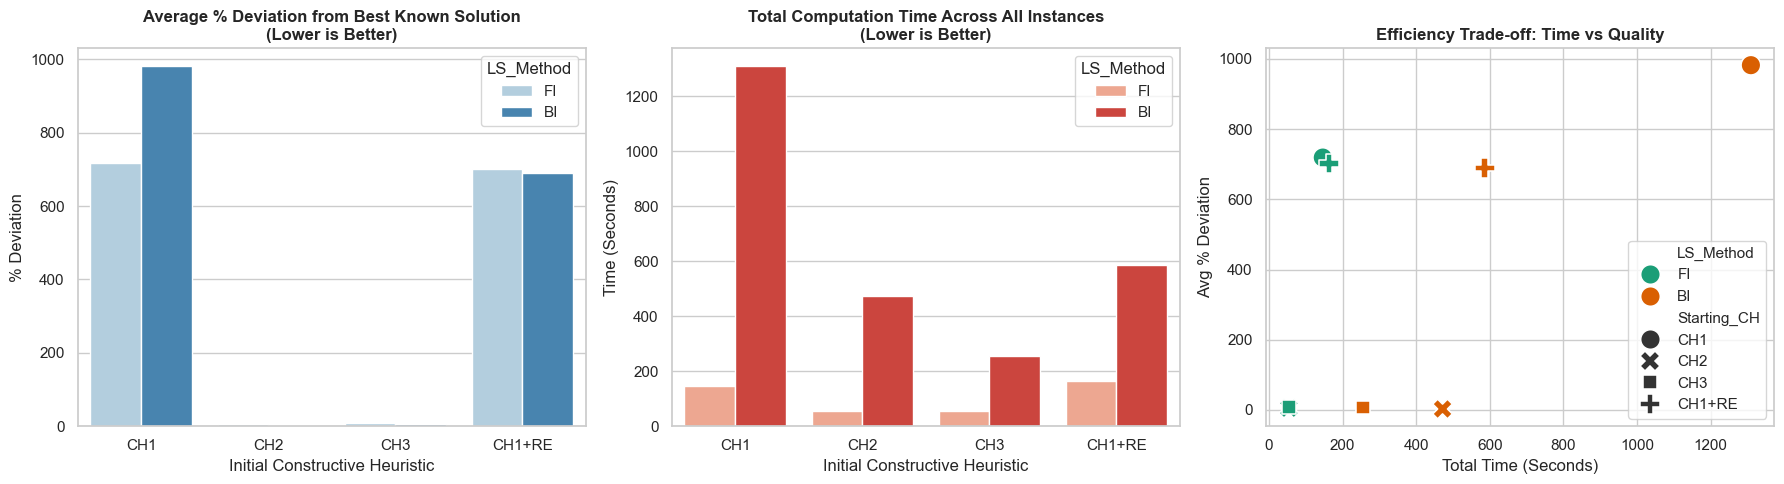

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your saved data
ls_report = pd.read_csv("scp_experiment_results.csv")

# 1. THE FIX: Use rsplit with n=1 to only split the very last '+' sign!
# "CH1+RE+FI" will now correctly become "CH1+RE" and "FI"
ls_report[['Starting_CH', 'LS_Method']] = ls_report['Algorithm'].str.rsplit('+', n=1, expand=True)

# Set the style for professional academic plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: Solution Quality (% Deviation) ---
sns.barplot(data=ls_report, x='Starting_CH', y='Avg % Dev', hue='LS_Method', ax=axes[0], palette="Blues")
axes[0].set_title('Average % Deviation from Best Known Solution\n(Lower is Better)', fontweight='bold')
axes[0].set_ylabel('% Deviation')
axes[0].set_xlabel('Initial Constructive Heuristic')

# --- PLOT 2: Computation Time ---
sns.barplot(data=ls_report, x='Starting_CH', y='Total Time (s)', hue='LS_Method', ax=axes[1], palette="Reds")
axes[1].set_title('Total Computation Time Across All Instances\n(Lower is Better)', fontweight='bold')
axes[1].set_ylabel('Time (Seconds)')
axes[1].set_xlabel('Initial Constructive Heuristic')

# --- PLOT 3: Time vs Quality Trade-off (Scatter) ---
sns.scatterplot(data=ls_report, x='Total Time (s)', y='Avg % Dev', hue='LS_Method', 
                style='Starting_CH', s=200, ax=axes[2], palette="Dark2")
axes[2].set_title('Efficiency Trade-off: Time vs Quality', fontweight='bold')
axes[2].set_xlabel('Total Time (Seconds)')
axes[2].set_ylabel('Avg % Deviation')

plt.tight_layout()
plt.show()